# 01 · 从 MLP 到自回归分解：链式法则是唯一的魔法

**读者画像**：已经会用 MLP（全连接网络 + 激活函数，输入一个向量、输出一个数），但没系统学过概率生成模型。

**本课目标**：

1. 说清楚"直接令 $p(x)=\mathrm{MLP}(x)$"为什么不行——负数、归一化、$2^N$ 配分函数三堵墙；
2. 学会用**链式法则**把联合分布拆成一串条件分布——这是恒等式，不是近似；
3. 用 jax 手写一个 3-bit 的最小自回归模型，**显式验证** $\sum_x p(x)=1$ 自动成立（网络完全没训练也成立）；
4. 建立"小系统可枚举、大系统靠采样"的意识，为 NQS/VMC 做铺垫。

**工具**：`jax` / `numpy` / `matplotlib`；随机种子已固定，可整本重跑复现。

## 0 · 你已经会的：MLP 是一台"确定性函数机器"

一个普通 MLP 是这样的映射：

$$y = f_\theta(x):\ \mathbb{R}^{d} \to \mathbb{R}^{m}$$

给定输入 $x$，它吐出一个**确定的**输出 $y$；$\theta$ 是权重。你在 NQS 里常见它作为波函数振幅网络 $\psi_\theta(x) \approx e^{f_\theta(x)}$，本质也是"输入构型 → 输出打分"。

**类比**：MLP 是一个**填空题高手**——给一道完整的题（输入 $x$），它一次填出答案（输出 $y$）。

本课想换一个任务：让神经网络表示一个**概率分布** $p(x)$。当 $x$ 是 $N$ 个比特时，这不是"一个函数值"，而是"每个构型各有多大可能"的一整张表，共有 $2^N$ 行。麻烦就出在这里。

## 1 · 天真方案：$p(x) = \mathrm{MLP}(x)$，为什么不行？

让 MLP 对每个构型 $x$ 输出一个数、直接当概率用，会接连撞上三堵墙：

1. **负数**：MLP 输出是任意实数，可能是 $-0.7$，而概率必须非负。（可补救：套一层 $\exp$ 或 sigmoid，这不是主要矛盾。）
2. **不归一化**：$\sum_x p(x) = 1$ 没有任何机制保证。
3. **配分函数墙**：想强制归一化，标准写法是

$$p(x) = \frac{e^{f_\theta(x)}}{Z_\theta}, \qquad Z_\theta = \sum_{x} e^{f_\theta(x)}.$$ 

这个 $Z_\theta$ 要对**全部 $2^N$ 个构型**求和：$N=3$ 时 8 项无所谓；$N=20$ 约一百万项；$N=40$ 约一万亿项；$N=100$ 时 $2^{100} \approx 10^{30}$——量子多体问题恰好就是这种 $N$（自旋数）。

另一种天真方案是让网络直接输出 $2^N$ 个数再 softmax——那输出层就得有 $2^N$ 个单元，比配分函数还不划算。

**类比**：归一化要求填空题高手"同时知道所有 $2^N$ 道题的答案，并把总分精确调成 100"。而 MLP 只会"给一道题、答一道题"，总分（$Z$）它根本够不着。

下面看概率论送上门的免费午餐。

## 2 · 链式法则：把一张 $2^N$ 行的大表，拆成一串小表

概率论的**恒等式**（严格等式，不是近似）：

$$p(x_1, x_2) = p(x_1)\, p(x_2 \mid x_1),$$

$$p(x_1, \dots, x_N) = \prod_{i=1}^{N} p(x_i \mid x_{<i}), \qquad x_{<i} \equiv (x_1, \dots, x_{i-1}).$$

**类比：逐字接龙。** 写一句话时，第一个字自由发挥（$p(x_1)$）；第二个字看着第一个字写（$p(x_2\mid x_1)$）；第三个字看着前两个字写……每个字的选择都是一次**局部合法**的选择。

**为什么乘起来自动归一化？** 层层求和会像望远镜一样逐级坍缩：

$$\sum_{x} p(x) = \sum_{x_1} p(x_1) \underbrace{\sum_{x_2} p(x_2 \mid x_1)}_{=\,1} \cdots \underbrace{\sum_{x_N} p(x_N \mid x_{<N})}_{=\,1} = 1.$$

只要**每个条件分布自己合法**（对 $x_i$ 求和为 1），乘积就**自动归一化**——完全不需要算 $Z$！这就是自回归模型的全部数学基础。

## 3 · 用 MLP 表示每个条件分布：条件化 + 参数共享

链式法则把问题变成了：怎么表示一个个条件分布 $p(x_i \mid x_{<i})$？

看清楚它的形状：**输入是前缀 $x_{<i}$，输出是第 $i$ 位取 1 的概率**——这正是一个普通函数，正是 MLP 擅长的事！只需两个工程细节：

- **定长输入**：前缀长短不一（第 1 位前面是空的，第 $N$ 位前面有 $N-1$ 位）。把输入槽固定为 $N-1$ 长：已生成的位填进去，还没生成的位**补 0 占位**；
- **参数共享**：$N$ 个条件分布用**同一个 MLP、同一组参数 $\theta$**。参数量不随 $N$ 翻倍，不同位学到的规律还能互相迁移。

以 $N=3$ 为例，同一个 MLP 被调用三次：

$$p(x_1) \leftarrow \mathrm{MLP}(0,\,0), \qquad p(x_2 \mid x_1) \leftarrow \mathrm{MLP}(x_1,\,0), \qquad p(x_3 \mid x_1, x_2) \leftarrow \mathrm{MLP}(x_1,\,x_2).$$

每个输出是一个 logit，过 sigmoid 得到"该位取 1"的条件概率（二分类时 sigmoid 就是 softmax）。

**"自回归"名字的由来**：模型自己的输出（已生成的位）会回流成为下一步的输入——auto（自己）+ regression（回归/预测）。

下面亲手写一个，验证它"天生归一化"。

In [1]:
import itertools

import numpy as np
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---- 中文字体：在 macOS 可用中文字体里挑第一个命中的 ----
for font in ["Hiragino Sans GB", "Arial Unicode MS", "Heiti TC", "STHeiti", "Songti SC", "PingFang SC"]:
    if font in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams["font.sans-serif"] = [font]
        print("绘图使用中文字体:", font)
        break
plt.rcParams["axes.unicode_minus"] = False

# ---- 固定随机种子，保证结果可复现 ----
np.random.seed(0)
key = jax.random.PRNGKey(0)
print("jax 版本:", jax.__version__)

绘图使用中文字体: Hiragino Sans GB
jax 版本: 0.9.2


In [2]:
# ---------- 手写一个最小的 MLP（输入层 → tanh 隐藏层 → 线性输出）----------
def init_mlp(rng, layer_sizes):
    """随机初始化普通全连接 MLP。layer_sizes 形如 [2, 8, 1]。"""
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        rng, sub = jax.random.split(rng)
        W = jax.random.normal(sub, (n_in, n_out)) * 0.5
        b = jnp.zeros(n_out)
        params.append((W, b))
    return params

def mlp(params, x):
    h = x
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b          # 输出 logit（普通 MLP，没有任何掩码）

rng, key = jax.random.split(key)
# 共享的条件分布网络：输入定长前缀（N-1 = 2 位），输出 1 个 logit
params_ar = init_mlp(rng, [2, 8, 1])
print("条件分布 MLP 的参数形状:", [(tuple(W.shape), tuple(b.shape)) for W, b in params_ar])

条件分布 MLP 的参数形状: [((2, 8), (8,)), ((8, 1), (1,))]


In [3]:
N = 3  # 比特数

def ar_logp(params, x):
    """自回归分解：log p(x) = log p(x1) + log p(x2|x1) + log p(x3|x1,x2)。
    同一个 MLP 调用 N 次：已生成的位填入定长前缀，未生成的位补 0 占位。"""
    logp = 0.0
    for i in range(N):
        prefix = jnp.zeros(N - 1).at[:i].set(x[:i])   # 定长前缀 + 0 占位
        logit = mlp(params, prefix)[0]                # 每次都是同一个网络、同一组参数
        # p(x_i=1|·) = sigmoid(logit)；用 log_sigmoid 保证数值稳定
        logp += jnp.where(x[i] == 1,
                          jax.nn.log_sigmoid(logit),
                          jax.nn.log_sigmoid(-logit))
    return logp

# ---------- 小系统：全空间枚举 2^N = 8 个构型 ----------
configs = np.array(list(itertools.product([0, 1], repeat=N)))      # (8, 3)
logps = jax.vmap(ar_logp, in_axes=(None, 0))(params_ar, jnp.asarray(configs))
probs = jnp.exp(logps)

print("构型      概率")
for c, p in zip(configs, probs):
    print(" ".join(map(str, c)), "     ", f"{float(p):.6f}")
print()
print(f"全空间概率总和 Σ_x p(x) = {float(probs.sum()):.12f}")
print("↑ 应为 1。注意：这个网络是随机初始化的，完全没训练过——归一化是结构送的。")

构型      概率
0 0 0       0.125000
0 0 1       0.125000
0 1 0       0.172058
0 1 1       0.077942
1 0 0       0.086791
1 0 1       0.121525
1 1 0       0.174769
1 1 1       0.116915

全空间概率总和 Σ_x p(x) = 1.000000000000
↑ 应为 1。注意：这个网络是随机初始化的，完全没训练过——归一化是结构送的。


Σ 恰好等于 1，精确到机器精度——**没有任何训练，没有任何配分函数**。

现在做对照实验：同样用一个随机初始化的 MLP，但按"填空题"的方式用它——把**整个构型** $x$ 一次性喂进去，输出 $N$ 个 logit，逐个过 sigmoid 后连乘当概率。看看还归一化吗？

自回归（链式法则）    Σ_x p(x) = 1.000000000000
朴素 MLP（逐位连乘）  Σ_x p(x) = 0.789723277092   ← 一般不等于 1！


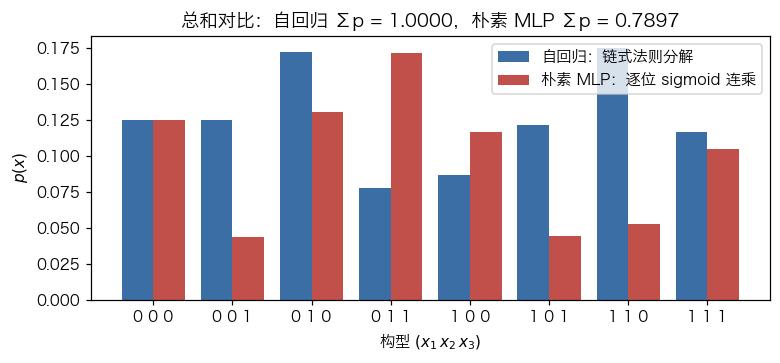

In [4]:
# ---------- 对照实验：把 MLP 当"填空题"直接给整个 x 打分 ----------
rng, key = jax.random.split(key)
params_naive = init_mlp(rng, [N, 8, N])    # 输入整个 x（3 位），输出 3 个 logit

def naive_prob(params, x):
    """朴素方案：p(x) = Π_i sigmoid(logit_i(x))，其中 logit_i 依赖【整个 x】。
    每位看似做了 sigmoid 归一化，但它归一化的是"固定整个 x 时第 i 位"——
    不同构型之间毫无约束。"""
    logits = mlp(params, x)
    return jnp.prod(jnp.where(x == 1, jax.nn.sigmoid(logits), 1.0 - jax.nn.sigmoid(logits)))

naive_probs = jax.vmap(naive_prob, in_axes=(None, 0))(params_naive, jnp.asarray(configs))

print(f"自回归（链式法则）    Σ_x p(x) = {float(probs.sum()):.12f}")
print(f"朴素 MLP（逐位连乘）  Σ_x p(x) = {float(naive_probs.sum()):.12f}   ← 一般不等于 1！")

# ---------- 画图对比 ----------
labels = [" ".join(map(str, c)) for c in configs]
xpos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7.2, 3.4), dpi=110)
ax.bar(xpos - 0.2, np.asarray(probs), width=0.4, color="#3b6ea5", label="自回归：链式法则分解")
ax.bar(xpos + 0.2, np.asarray(naive_probs), width=0.4, color="#c2504a", label="朴素 MLP：逐位 sigmoid 连乘")
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_xlabel("构型 $(x_1\\,x_2\\,x_3)$")
ax.set_ylabel("$p(x)$")
ax.set_title(f"总和对比：自回归 Σp = {float(probs.sum()):.4f}，朴素 MLP Σp = {float(naive_probs.sum()):.4f}")
ax.legend()
plt.tight_layout()
plt.show()

## 4 · 解读：为什么"每位都过了 sigmoid"还是不归一化？

朴素方案里 $\mathrm{sigmoid}(\mathrm{logit}_i(x))$ 确实是个 0 到 1 之间的数，但它回答的问题是：

> "把**整个构型** $x$ 端上来时，网络觉得第 $i$ 位像 1 的程度。"

换一个构型 $x'$，$\mathrm{logit}_i$ 也跟着变——所以"第 $i$ 位取 0 的概率 + 取 1 的概率 = 1"这种**局部合法性根本不存在**，乘起来自然对不上 1。

链式法则里的因子则回答完全不同的问题：

> "**前缀 $x_{<i}$ 已经固定**时，第 $i$ 位取 1 的概率。"

此时对 $x_i \in \{0,1\}$ 求和恰好把 sigmoid 的两支加起来、等于 1，telescope 求和逐级坍缩，总和必然是 1。**合法性来自"固定前缀"这个因果结构，而不是来自训练，也不是来自 sigmoid 本身。**

如果非要给朴素方案凑归一化，就回到 $p(x) = e^{f_\theta(x)} / Z_\theta$，需要枚举 $2^N$ 项算 $Z$——这正是传统 NQS（RBM、前馈振幅网络）的做法，也正因为 $Z$ 难算，才要靠蒙特卡洛采样绕开它。自回归模型把这件事从根上免掉了。

In [5]:
# ---------- 指数墙有多大？----------
print(f"{'N':>4} {'2^N':>16}   直观感受")
for n, feel in [(3, "本课的玩具"), (10, "千"), (20, "约一百万"),
                (30, "约十亿"), (40, "约一万亿"), (60, "远超任何算力"), (100, "≈ 10^30，望洋兴叹")]:
    print(f"{n:>4} {2**n:>16,}   {feel}")

   N              2^N   直观感受
   3                8   本课的玩具
  10            1,024   千
  20        1,048,576   约一百万
  30    1,073,741,824   约十亿
  40 1,099,511,627,776   约一万亿
  60 1,152,921,504,606,846,976   远超任何算力
 100 1,267,650,600,228,229,401,496,703,205,376   ≈ 10^30，望洋兴叹


## 5 · 小系统可枚举，大系统靠采样

本课的 3-bit 玩具系统只有 8 个构型，可以把 $p(x)$ **整张表**枚举出来核对。但 NQS/VMC 面对的真实系统：$N$ 是自旋数，动辄几十上百，Hilbert 空间 $2^N$ 指数大——**任何"把表列出来"的想法都必须放弃**，归一化、期望值统统改用蒙特卡洛采样：

$$\langle O \rangle_{p} \approx \frac{1}{M} \sum_{s=1}^{M} O(x_s), \qquad x_s \sim p(x).$$

自回归分布对这件事意外地友好：虽然大系统里验证 $\sum_x p(x) = 1$ 不再可能，但**单个构型的 $\log p(x) = \sum_i \log p(x_i \mid x_{<i})$ 无需 $Z$ 就能逐点算出**——采样和权重计算都只需要"逐点前向"，这是后面一切内容的基础。

| | 直接 $e^{f}/Z$（传统 NQS） | 自回归分解 |
|---|---|---|
| 合法性来源 | 显式配分函数 $Z$ | 链式法则结构 |
| 算单个 $\log p(x)$ | 一次前向 | $N$ 次条件前向（下一课优化成一次） |
| 归一化 | 需要枚举/估计 $Z$ | **自动成立** |

## 6 · 本课小结

一句话直觉：

> **自回归 = MLP（你会的部分） + 链式法则（数学免费） + 条件化因果序（"只许看前面"的结构约定）。**

- **MLP** 提供表达力：每个条件分布就是一个普通函数，你还是只需要会 MLP；
- **链式法则** 保证归一化：只要每个因子合法，乘积自动合法，$Z$ 免算；
- **因果序** 是我们自己选的：$x_1 \to x_2 \to \cdots \to x_N$，接龙的顺序。

**遗留问题**：上面为了算一个 $p(x)$，把共享 MLP 循环调用了 $N$ 次——太慢。能不能用**一个 MLP 的一次前向**同时输出所有 $N$ 个条件分布，同时严格保证第 $i$ 个输出"偷看"不到第 $i$ 位及之后的任何输入？

答案是把"不许偷看"直接**焊进网络结构**：掩码全连接层（MADE）。下一课见。